In [3]:
import numpy as np
# preparing data for rnn

import torch
import joblib

from pathlib import Path

from features.tokenizer import Vocabulary


In [5]:
vocabulary = Vocabulary()

In [7]:
from data.dataset import get_corpus

X_train, y_train, X_val, y_val, X_test, y_test = get_corpus()

In [8]:
vocabulary.build(X_train)

  0%|          | 0/71487 [00:00<?, ?it/s]/home/letharic/anaconda3/lib/python3.13/site-packages/spacy/pipeline/lemmatizer.py:187: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)
100%|██████████| 71487/71487 [04:12<00:00, 282.96it/s]


In [10]:
import pandas as pd

In [15]:
t = pd.DataFrame({
    "a": ["b", "c"]
})

t['b'] = [[1, 2], [3, 4]]

t

,a,b
0,b,"[1, 2]"
1,c,"[3, 4]"


In [12]:
from tqdm import tqdm

train_df = pd.DataFrame({
    "text": X_train,
    "toxic": y_train
})

train_df["tokens"] = train_df["text"].apply(vocabulary.encode_one)

ValueError: Expected a 1D array, got an array with shape (71487, 150)

In [16]:
val_df = pd.DataFrame({
    "text": X_val,
    "toxic": y_val
})

val_df["tokens"] = val_df["text"].apply(vocabulary.encode_one)

/home/letharic/anaconda3/lib/python3.13/site-packages/spacy/pipeline/lemmatizer.py:187: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


In [30]:
train_df = pd.DataFrame({
    "text": X_train,
    "toxic": y_train
})

train_df["tokens"] = train_df["text"].apply(vocabulary.encode_one)

/home/letharic/anaconda3/lib/python3.13/site-packages/spacy/pipeline/lemmatizer.py:187: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


In [32]:
joblib.dump(train_df, "../data/rnn/train.pkl")

['./train.pkl']

In [33]:
test_df = pd.DataFrame({
    "text": X_test,
    "toxic": y_test
})

test_df["tokens"] = test_df["text"].apply(vocabulary.encode_one)

/home/letharic/anaconda3/lib/python3.13/site-packages/spacy/pipeline/lemmatizer.py:187: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


In [34]:
joblib.dump(test_df, "../data/rnn/test.pkl")

['./test.pkl']

In [45]:
torch.stack(train_df['tokens'].to_list())

tensor([[   0,    0,    0,  ...,    1,    7,    1],
        [  10,   45,   46,  ...,  113,  114,    1],
        [   0,    0,    0,  ...,  142,   87,    1],
        ...,
        [   0,    0,    0,  ...,   90, 1057,    1],
        [   0,    0,    0,  ...,    1,  142,    1],
        [   0,    0,    0,  ...,  372,  481,    1]])

In [3]:
import matplotlib.pyplot as plt
import numpy as np

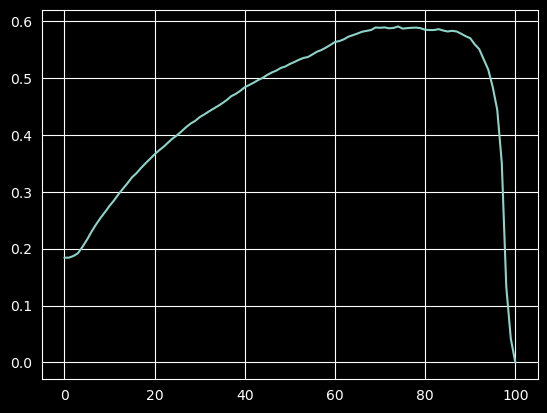

In [4]:
plt.plot(np.linspace(0, 100, 101), [
0.1840, 0.1842, 0.1870, 0.1918, 0.2030, 0.2155, 0.2295, 0.2422, 0.2537,
0.2641, 0.2750, 0.2846, 0.2956, 0.3054, 0.3149, 0.3253, 0.3326, 0.3417,
0.3499, 0.3577, 0.3656, 0.3726, 0.3789, 0.3863, 0.3935, 0.3992, 0.4062,
0.4134, 0.4197, 0.4243, 0.4309, 0.4356, 0.4407, 0.4455, 0.4502, 0.4553,
0.4609, 0.4677, 0.4718, 0.4771, 0.4835, 0.4874, 0.4916, 0.4962, 0.5000,
0.5052, 0.5094, 0.5127, 0.5174, 0.5199, 0.5243, 0.5278, 0.5316, 0.5349,
0.5365, 0.5410, 0.5458, 0.5488, 0.5531, 0.5579, 0.5629, 0.5646, 0.5677,
0.5723, 0.5750, 0.5778, 0.5809, 0.5825, 0.5840, 0.5884, 0.5879, 0.5886,
0.5870, 0.5877, 0.5902, 0.5865, 0.5873, 0.5879, 0.5882, 0.5872, 0.5844,
0.5839, 0.5840, 0.5855, 0.5831, 0.5814, 0.5826, 0.5814, 0.5774, 0.5731,
0.5696, 0.5588, 0.5504, 0.5323, 0.5145, 0.4836, 0.4436, 0.3508, 0.1327,
0.0421, 0.0
])